# 04 - Clustering

**Phases 5 to 7.** Encoding, scaling, K-Means, elbow and silhouette, then
hierarchical validation.

The search is run as a grid over *feature set x scaler x K*, and every cell is
scored on more than cluster compactness - because on this dataset the highest
silhouette score belongs to a solution that has discovered nothing at all.


In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

from src import config as cfg, visuals as vz
from src.clustering import (compare_partitions, elbow_k, eta_squared,
                            fit_hierarchical, fit_kmeans, index_consensus,
                            pca_projection, run_experiment, scan_k,
                            select_best, silhouette_by_cluster,
                            stability_check)
from src.preprocessing import FEATURE_SETS, build_matrix
vz.apply_style()
features = pd.read_csv(cfg.CLIENT_FEATURES)

for name, fs in FEATURE_SETS.items():
    print(f"{name:22s} {fs.description}")


behaviour_core         Six de-correlated investment-behaviour features only.
behaviour_wide         Every behavioural feature the PRD lists, including the collinear area and tower restatements.
behaviour_demo         Behavioural core plus age and satisfaction.
behaviour_demo_flags   Behavioural core, demographics and the four binary buyer flags.
prd_encoded            Adds one-hot gender, referral channel and country to the above.
prd_full               Literal PRD encoding: everything above plus one-hot region (57 levels).


## The grid search

In [2]:
experiment = run_experiment(features)
cols = ['feature_set','scaler','k','silhouette','davies_bouldin',
        'behavioural_separation','declared_separation','min_cluster_size',
        'actionable','substantive']
print("Top 8 by raw silhouette, ignoring all substance checks:")
experiment.sort_values('silhouette', ascending=False).head(8)[cols].round(4)


Top 8 by raw silhouette, ignoring all substance checks:


,feature_set,scaler,k,silhouette,davies_bouldin,behavioural_separation,declared_separation,min_cluster_size,actionable,substantive
94,behaviour_demo_flags,minmax,6,0.3246,1.3052,0.0029,0.4575,115,True,False
93,behaviour_demo_flags,minmax,5,0.3022,1.3620,0.0021,0.4155,234,True,False
96,behaviour_demo_flags,minmax,8,0.2865,1.3591,0.0039,0.5319,115,True,False
98,behaviour_demo_flags,minmax,10,0.2701,1.4260,0.0068,0.5683,57,True,False
95,behaviour_demo_flags,minmax,7,0.2632,1.4417,0.0038,0.5054,172,True,False
97,behaviour_demo_flags,minmax,9,0.2616,1.4389,0.0049,0.5554,115,True,False
92,behaviour_demo_flags,minmax,4,0.2607,1.3416,0.0022,0.3836,387,True,False
91,behaviour_demo_flags,minmax,3,0.2558,1.4851,0.0005,0.2819,502,True,False


### Why the leader is rejected

The top solution reaches silhouette 0.32 - but its behavioural separation is
0.003, meaning it explains essentially **none** of the variance in what
clients bought. Min-max scaling puts the binary buyer flags on the corners of
the unit cube, and K-Means simply walks to them.


In [3]:
X_bad, _, _ = build_matrix(features, FEATURE_SETS['behaviour_demo_flags'], 'minmax')
bad = fit_kmeans(X_bad, 6).labels_
e = eta_squared(features, bad, ['loan_flag','is_investment','is_domestic',
                                'total_investment','total_properties',
                                'avg_property_price','office_share'])
print("Variance explained by that 'best' 6-cluster solution:")
print(e.round(4).sort_values(ascending=False).to_string())
print()
from src.clustering import flag_redundancy
print("Adjusted Rand index vs the raw crosstab of the four binary flags:",
      round(flag_redundancy(features, bad), 3))
print("=> 0.9 means K-Means re-derived a groupby. That is not a discovered segment.")


Variance explained by that 'best' 6-cluster solution:
loan_flag             1.0000
is_domestic           0.8786
is_investment         0.8561
total_investment      0.0040
total_properties      0.0036
avg_property_price    0.0018
office_share          0.0017



Adjusted Rand index vs the raw crosstab of the four binary flags: 0.896
=> 0.9 means K-Means re-derived a groupby. That is not a discovered segment.


So the search applies two gates before ranking:

* **actionable** - no segment smaller than 25 clients;
* **substantive** - the partition must explain more variance in what clients
  *bought* than in what they *declared*.

Survivors are then ranked by how many of the three internal indices
independently choose that K. That last step matters: silhouette and
Calinski-Harabasz both drift upward as K falls, so ranking on either alone
returns the degenerate K = 2.


In [4]:
print("Viable solutions, best first:")
display(experiment[experiment.viable].sort_values('silhouette', ascending=False).head(8)[cols].round(4))
print()
print("Which K each index picks, per configuration:")
display(index_consensus(experiment).sort_values('n_indices_agreeing', ascending=False).head(8))


Viable solutions, best first:


,feature_set,scaler,k,silhouette,davies_bouldin,behavioural_separation,declared_separation,min_cluster_size,actionable,substantive
45,behaviour_wide,log_standard,2,0.2501,1.5760,0.1511,0.0007,961,True,True
47,behaviour_wide,log_standard,4,0.2420,1.2286,0.3705,0.0021,39,True,True
48,behaviour_wide,log_standard,5,0.2336,1.2496,0.4107,0.0022,38,True,True
29,behaviour_wide,standard,4,0.2280,1.2745,0.3737,0.0022,39,True,True
46,behaviour_wide,log_standard,3,0.2262,1.3740,0.2793,0.0012,453,True,True
28,behaviour_wide,standard,3,0.2253,1.3282,0.3021,0.0015,42,True,True
30,behaviour_wide,standard,5,0.2214,1.3018,0.4124,0.0020,39,True,True
9,behaviour_core,minmax,2,0.2199,1.6969,0.1376,0.0006,911,True,True



Which K each index picks, per configuration:


,feature_set,scaler,k,n_indices_agreeing,voted_by
9,behaviour_demo,minmax,2,3,"calinski_harabasz,davies_bouldin,silhouette"
25,behaviour_wide,standard,4,3,"calinski_harabasz,davies_bouldin,silhouette"
7,behaviour_demo,log_standard,2,2,"calinski_harabasz,silhouette"
2,behaviour_core,minmax,2,2,"calinski_harabasz,silhouette"
39,prd_full,standard,2,2,"calinski_harabasz,silhouette"
16,behaviour_demo_flags,minmax,6,2,"davies_bouldin,silhouette"
21,behaviour_wide,log_standard,2,2,"calinski_harabasz,silhouette"
37,prd_full,minmax,2,2,"calinski_harabasz,silhouette"


In [5]:
best = select_best(experiment)
fs_name, scaler, k = best['feature_set'], best['scaler'], int(best['k'])
print(f"SELECTED: {fs_name} / {scaler} / K={k}")
print(f"  silhouette {best['silhouette']:.4f} | davies-bouldin {best['davies_bouldin']:.4f}"
      f" | calinski-harabasz {best['calinski_harabasz']:.1f}")
print(f"  indices agreeing: {best['voted_by']} ({int(best['n_indices_agreeing'])} of 3)")


SELECTED: behaviour_wide / standard / K=4
  silhouette 0.2280 | davies-bouldin 1.2745 | calinski-harabasz 618.8
  indices agreeing: calinski_harabasz,davies_bouldin,silhouette (3 of 3)


## Elbow and silhouette curves for the selected representation

,k,inertia,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,min_cluster_pct
0,2,15355.4011,0.2187,604.3417,1.6515,916,0.4580
1,3,12490.4526,0.2253,600.3228,1.3282,42,0.0210
2,4,10362.7589,0.2280,618.7579,1.2745,39,0.0195
3,5,9048.4293,0.2214,603.6513,1.3018,39,0.0195
4,6,8403.4676,0.2103,550.3320,1.3715,39,0.0195
5,7,7908.3393,0.1849,507.8748,1.5145,38,0.0190
6,8,7435.4290,0.1853,480.8768,1.4557,38,0.0190
7,9,7080.3981,0.1912,454.1222,1.4698,38,0.0190
8,10,6773.0100,0.1936,431.8072,1.4829,38,0.0190


elbow K = 5


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


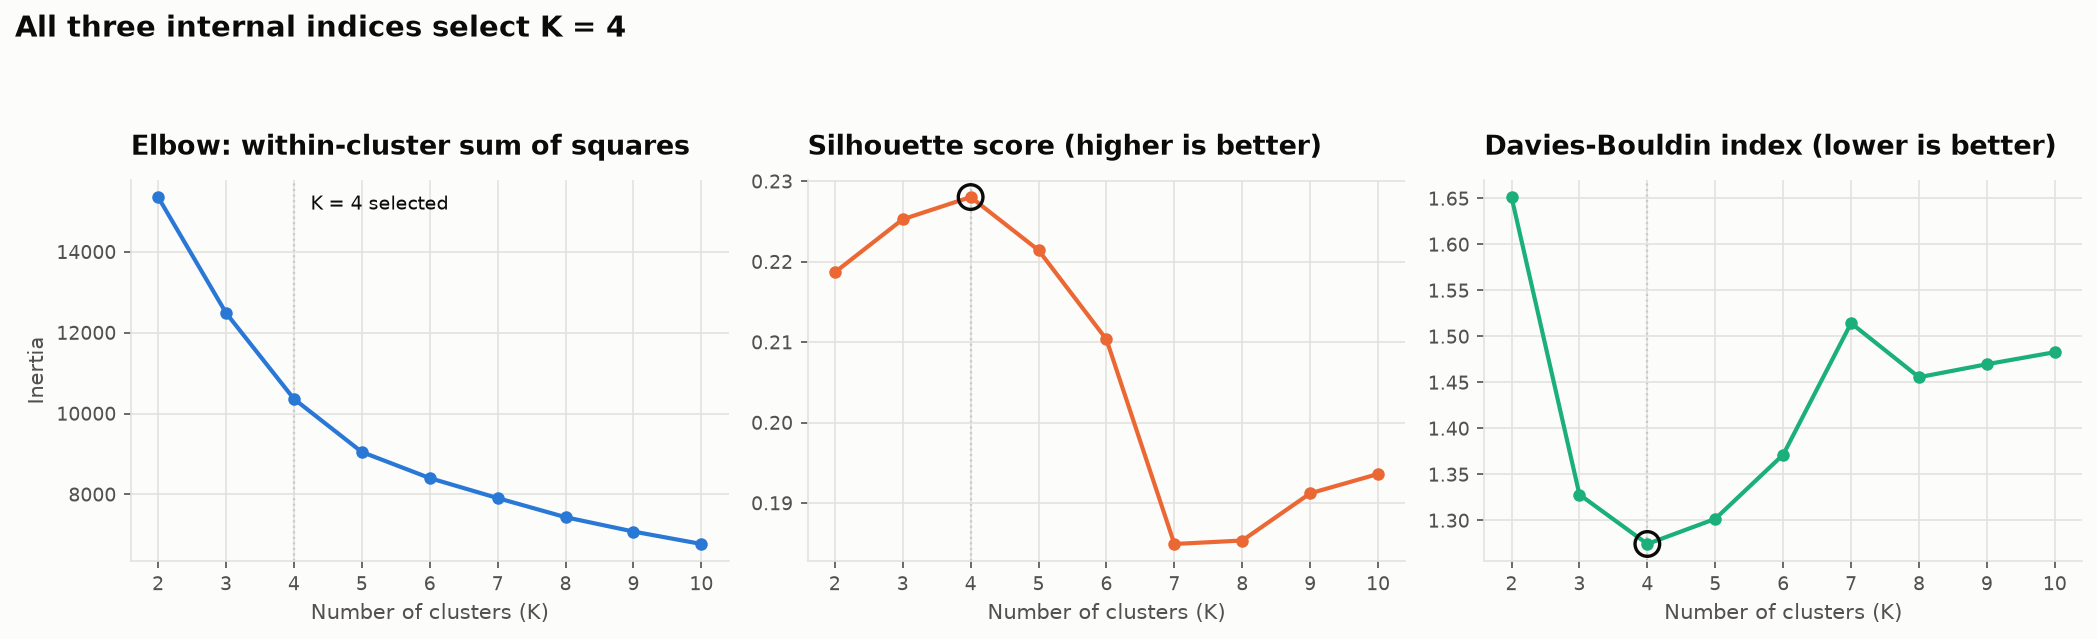

In [6]:
X, names, pre = build_matrix(features, FEATURE_SETS[fs_name], scaler)
scan = scan_k(X)
display(scan.round(4))
print("elbow K =", elbow_k(scan['k'].tolist(), scan['inertia'].tolist()))
from IPython.display import Image, display as disp
disp(Image(str(vz.fig_elbow_silhouette(scan, k))))


## Final fit, stability and hierarchical validation

In [7]:
km = fit_kmeans(X, k)
labels = km.labels_
print("cluster sizes:", np.bincount(labels).tolist())
display(silhouette_by_cluster(X, labels).round(3))

st = stability_check(X, k, n_runs=100)
print(f"bootstrap over 100 x 80% subsamples: mean ARI {st['mean_ari']:.3f} "
      f"(sd {st['std_ari']:.3f}, min {st['min_ari']:.3f})")


cluster sizes: [516, 766, 679, 39]


,cluster,mean,min,max,size
0,0,0.204,-0.015,0.363,516
1,1,0.239,0.007,0.424,766
2,2,0.223,-0.018,0.436,679
3,3,0.471,0.006,0.606,39


bootstrap over 100 x 80% subsamples: mean ARI 0.914 (sd 0.154, min 0.301)


Ward linkage, cophenetic correlation 0.407
hierarchical sizes: [421, 548, 35, 996]
agreement with K-Means: {'adjusted_rand': 0.573, 'adjusted_mutual_info': 0.614}


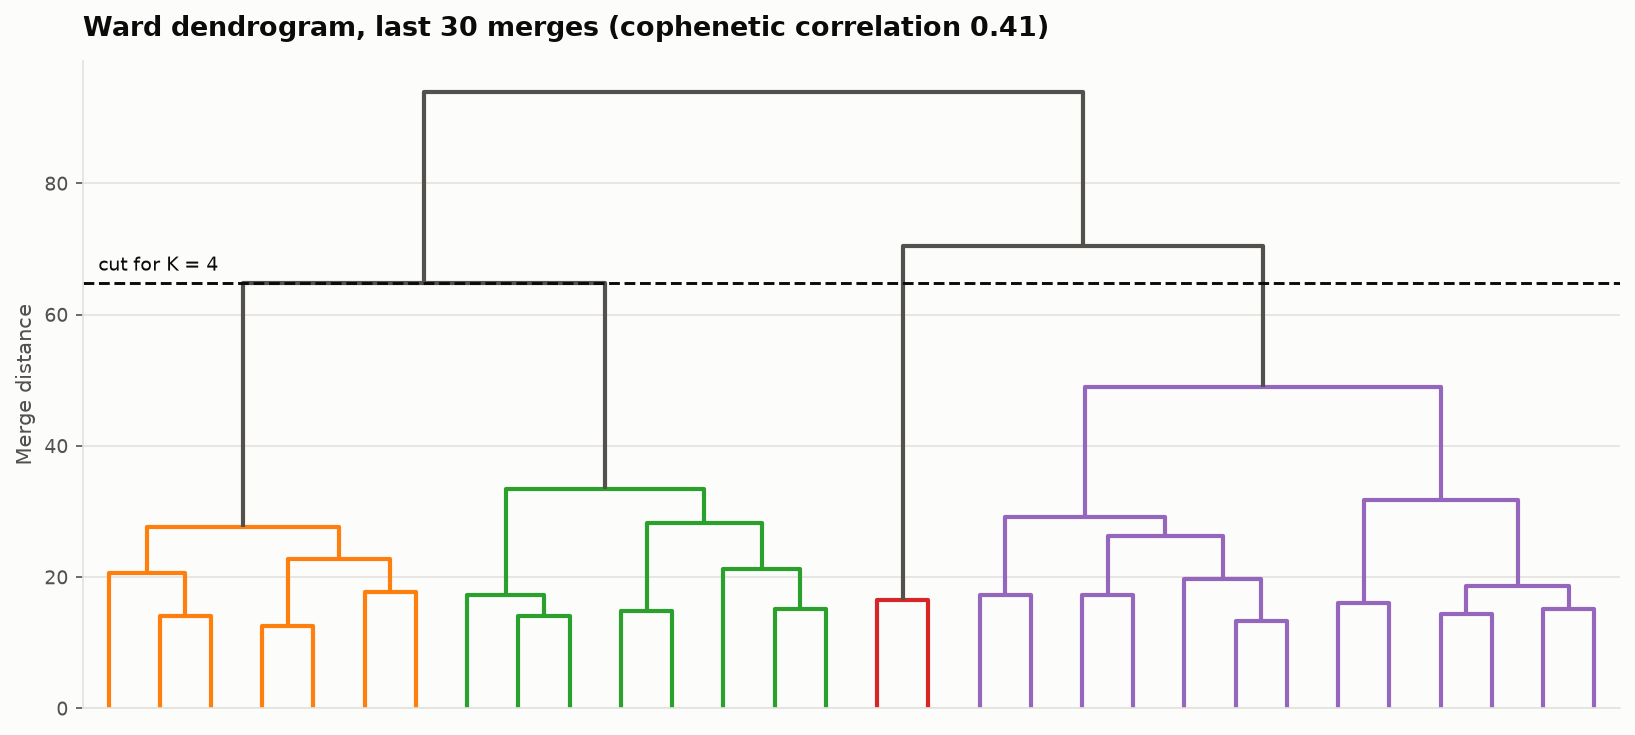

In [8]:
hier, Z, ccc = fit_hierarchical(X, k)
print(f"Ward linkage, cophenetic correlation {ccc:.3f}")
print("hierarchical sizes:", np.bincount(hier).tolist())
print("agreement with K-Means:", {a: round(b, 3) for a, b in compare_partitions(labels, hier).items()})
disp(Image(str(vz.fig_dendrogram(Z, k, ccc))))
